# Round 3 — Trader Identification

The public trade tape has `buyer` and `seller` columns that are **100% NaN** — we don't get counterparty IDs. But distinct traders leave distinct fingerprints. By clustering trades across:

- **Product** (what they trade)
- **Direction** (always buy / always sell / balanced)
- **Size signature** (what order sizes they use)
- **Timing** (regular, bursty, clock-driven)
- **Co-occurrence** (which products they trade *together*)

...we can reconstruct 5 distinct participants.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns
from pathlib import Path

sns.set_theme(style='white', context='notebook')
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.titleweight': 'bold', 'axes.titlesize': 12,
    'axes.labelsize': 10, 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.grid': True,
    'grid.alpha': 0.2, 'grid.linewidth': 0.6,
})

DATA_DIR = Path('../../data/ROUND_3')

TRADER_COLORS = {
    'Wing Seller':        '#d62728',
    'VELVET Accumulator': '#2ca02c',
    'VELVET Two-Way':     '#1f77b4',
    'HYDROGEL Trader':    '#9467bd',
    'VEV_4000 Trader':    '#ff7f0e',
}
DAY_COLORS = {0: '#1b4f8f', 1: '#f28e2b', 2: '#b02a37'}

In [2]:
prices = pd.concat([
    pd.read_csv(DATA_DIR / f'prices_round_3_day_{d}.csv', sep=';').assign(day=d)
    for d in (0, 1, 2)
], ignore_index=True)
trades = pd.concat([
    pd.read_csv(DATA_DIR / f'trades_round_3_day_{d}.csv', sep=';').assign(day=d)
    for d in (0, 1, 2)
], ignore_index=True)

# Annotate each trade with direction vs bid/ask + signed quantity
def annotate_all():
    parts = []
    for sym in trades['symbol'].unique():
        t = trades[trades['symbol']==sym].copy()
        p = prices[prices['product']==sym][['timestamp','day','bid_price_1','ask_price_1','mid_price']]
        m = t.merge(p, on=['timestamp','day'], how='left')
        m['direction'] = np.where(m['price'] >= m['ask_price_1'], 'BUY',
                         np.where(m['price'] <= m['bid_price_1'], 'SELL', 'MID'))
        m['signed_qty'] = np.where(m['direction']=='BUY', m['quantity'],
                          np.where(m['direction']=='SELL', -m['quantity'], 0))
        parts.append(m)
    return pd.concat(parts, ignore_index=True).sort_values(['day','timestamp']).reset_index(drop=True)

tt = annotate_all()
print(f'Annotated {len(tt):,} trades across {tt["symbol"].nunique()} symbols.')
print(f'Direction breakdown: {tt["direction"].value_counts().to_dict()}')

Annotated 4,048 trades across 12 symbols.
Direction breakdown: {'SELL': 2511, 'BUY': 1536, 'MID': 1}


## Fingerprint matrix — the first clue

For every symbol: how one-sided is the flow? This gives us the first trader split. Products where the flow is **~50/50** are market-maker-taken (two-way traders). Products where the flow is **100% one-sided** have a single directional participant.

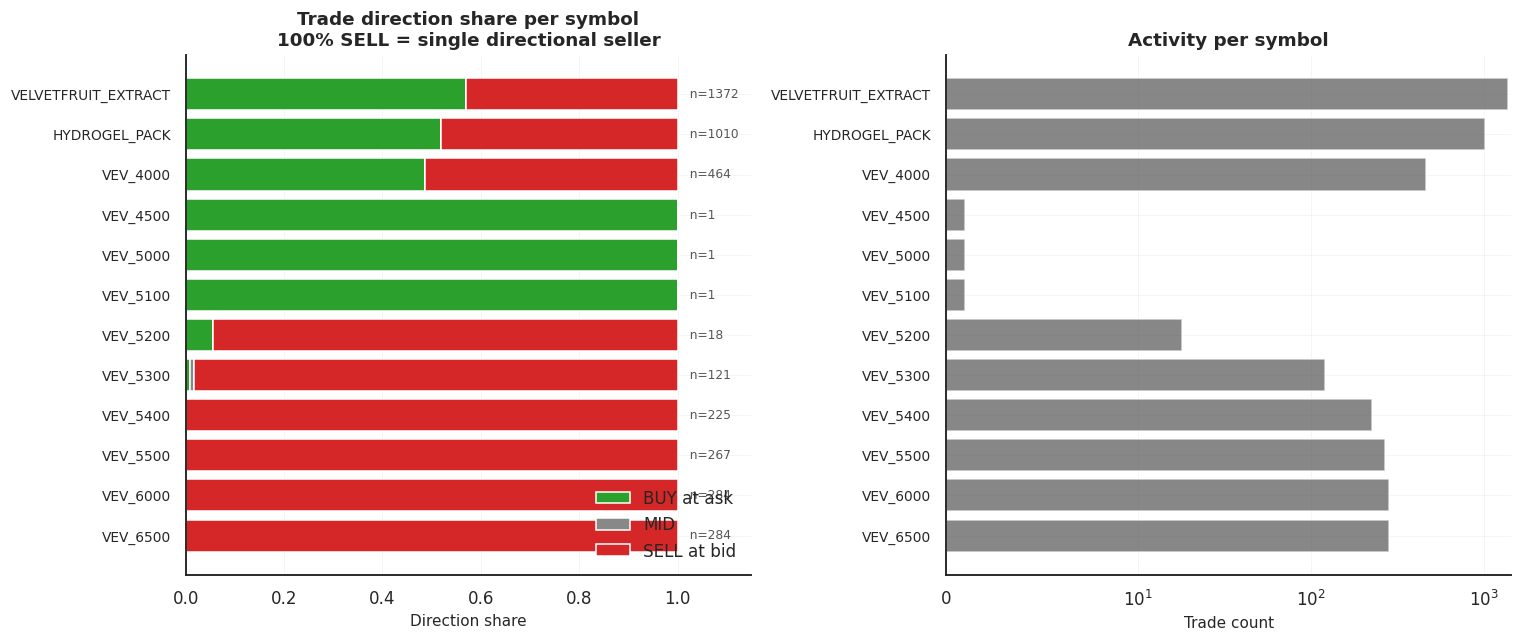

In [3]:
STRIKES = [4000,4500,5000,5100,5200,5300,5400,5500,6000,6500]
order = ['VELVETFRUIT_EXTRACT','HYDROGEL_PACK'] + [f'VEV_{k}' for k in STRIKES]

dir_cnt = tt.groupby(['symbol','direction']).size().unstack(fill_value=0).reindex(order)
dir_cnt = dir_cnt.reindex(columns=['BUY','MID','SELL'], fill_value=0)
total = dir_cnt.sum(axis=1)
dir_pct = dir_cnt.div(total, axis=0).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
y = np.arange(len(dir_pct))[::-1]
ax.barh(y, dir_pct['BUY'], color='#2ca02c', label='BUY at ask')
ax.barh(y, dir_pct['MID'], left=dir_pct['BUY'], color='#888', label='MID')
ax.barh(y, dir_pct['SELL'], left=dir_pct['BUY']+dir_pct['MID'], color='#d62728', label='SELL at bid')
for yi, tot in zip(y, total.values):
    ax.text(1.01, yi, f'  n={tot}', va='center', fontsize=8, color='#555')
ax.set_yticks(y); ax.set_yticklabels(dir_pct.index, fontsize=9)
ax.set_xlim(0, 1.15)
ax.set_xlabel('Direction share')
ax.set_title('Trade direction share per symbol\n100% SELL = single directional seller')
ax.legend(loc='lower right', frameon=False)

ax = axes[1]
cnt = tt.groupby('symbol').size().reindex(order)
ax.barh(y, cnt.values, color='#555', alpha=0.7)
ax.set_yticks(y); ax.set_yticklabels(order, fontsize=9)
ax.set_xlabel('Trade count')
ax.set_title('Activity per symbol')
ax.set_xscale('symlog', linthresh=10)
plt.tight_layout()
plt.show()

**What we can already see:**
- `VEV_5300` through `VEV_6500` are ~100% SELL — a single selling participant
- `VELVET`, `HYDROGEL`, `VEV_4000` are ~50/50 — two-way flow
- `VEV_4500`, `VEV_5000`, `VEV_5100`, `VEV_5200` barely trade (1–20 trades)

---
## Trader 1 — The Wing Seller

**Products:** `VEV_5300`, `VEV_5400`, `VEV_5500`, `VEV_6000`, `VEV_6500`

**Strategy:** Short OTM call wing (theta farming). Sells baskets of OTM calls at bid simultaneously.

**Smoking gun:** every single OTM call trade is a basket event where multiple strikes hit bid at the *same timestamp*. The table below lists the unique basket compositions.

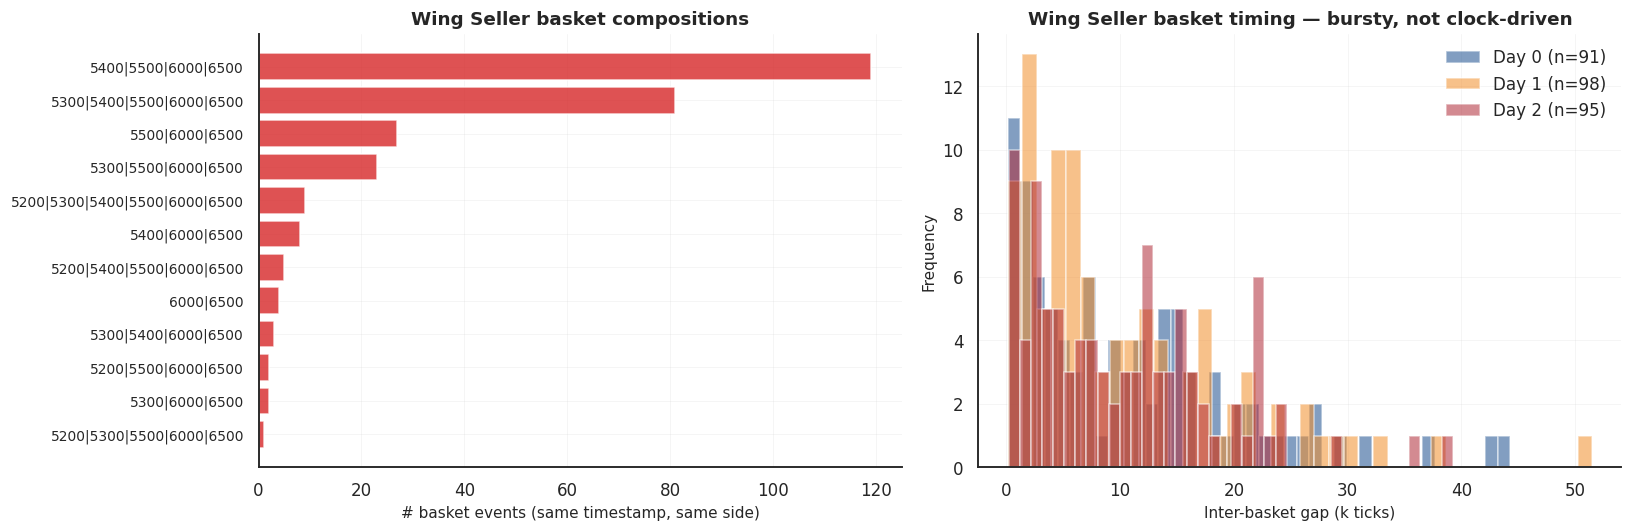

In [4]:
# Basket composition
wing_syms = ['VEV_5200','VEV_5300','VEV_5400','VEV_5500','VEV_6000','VEV_6500']
wing = tt[tt['symbol'].isin(wing_syms) & (tt['direction']=='SELL')]
basket = (wing.groupby(['day','timestamp'])['symbol']
          .apply(lambda x: '|'.join(sorted(x.unique()))).reset_index(name='basket'))
basket_counts = basket['basket'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar of basket compositions
ax = axes[0]
labels = basket_counts.index.tolist()
short = [l.replace('VEV_','') for l in labels]
ax.barh(range(len(labels))[::-1], basket_counts.values, color=TRADER_COLORS['Wing Seller'], alpha=0.8)
ax.set_yticks(range(len(labels))[::-1])
ax.set_yticklabels(short, fontsize=9)
ax.set_xlabel('# basket events (same timestamp, same side)')
ax.set_title('Wing Seller basket compositions')

# Timing - inter-basket gaps
ax = axes[1]
basket_events = basket.sort_values(['day','timestamp'])
for d in (0,1,2):
    ts = basket_events[basket_events['day']==d]['timestamp'].values
    gaps = np.diff(ts) / 1000
    ax.hist(gaps, bins=40, color=DAY_COLORS[d], alpha=0.55, label=f'Day {d} (n={len(ts)})')
ax.set_xlabel('Inter-basket gap (k ticks)')
ax.set_ylabel('Frequency')
ax.set_title('Wing Seller basket timing — bursty, not clock-driven')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

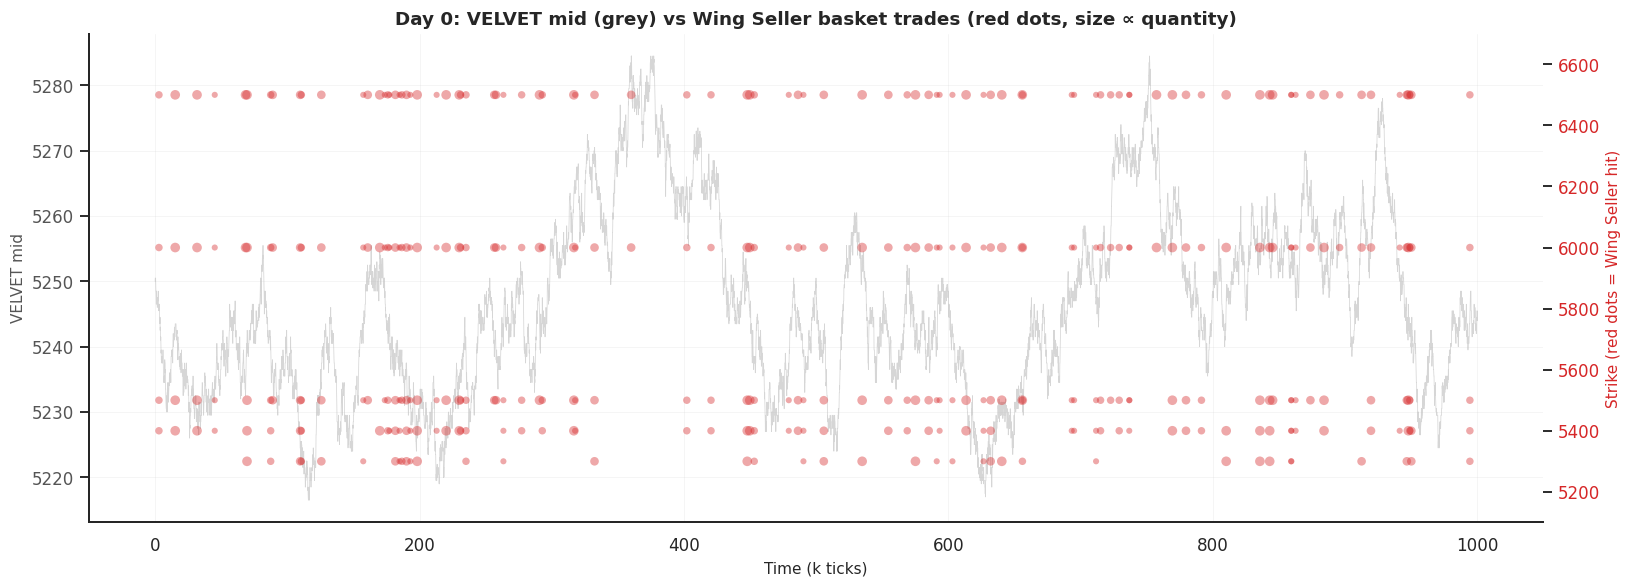

In [5]:
# Visualize the basket trades on a price backdrop for day 0
fig, ax = plt.subplots(figsize=(15, 5.5))
d = 0
und = prices[(prices['product']=='VELVETFRUIT_EXTRACT') & (prices['day']==d)]
ax.plot(und['timestamp']/1000, und['mid_price'], color='#bbb', lw=0.5, alpha=0.6)
ax.set_ylabel('VELVET mid', color='#555')
ax.tick_params(axis='y', labelcolor='#555')

ax2 = ax.twinx()
wing_d0 = wing[wing['day']==d]
strike_map = {'VEV_5300':5300,'VEV_5400':5400,'VEV_5500':5500,'VEV_6000':6000,'VEV_6500':6500}
for sym, strike in strike_map.items():
    sub = wing_d0[wing_d0['symbol']==sym]
    ax2.scatter(sub['timestamp']/1000, [strike]*len(sub), s=sub['quantity']*8,
                color=TRADER_COLORS['Wing Seller'], alpha=0.4, edgecolors='none')
ax2.set_ylim(5100, 6700)
ax2.set_ylabel('Strike (red dots = Wing Seller hit)', color=TRADER_COLORS['Wing Seller'])
ax2.tick_params(axis='y', labelcolor=TRADER_COLORS['Wing Seller'])
ax2.grid(False)
ax.set_xlabel('Time (k ticks)')
ax.set_title(f'Day 0: VELVET mid (grey) vs Wing Seller basket trades (red dots, size ∝ quantity)')
plt.tight_layout()
plt.show()

---
## Trader 2 — The VELVET Accumulator (Big Buyer)

**Discovered by:** size distribution split. VELVET sizes 3–8 are *balanced* buy/sell. Sizes **9–15 are 99% BUY** — a separate directional participant with a distinct size signature.

This trader never takes the sell side, never coincides with other products, and accumulates ~1100 VELVET units of net long exposure across the 3 days.

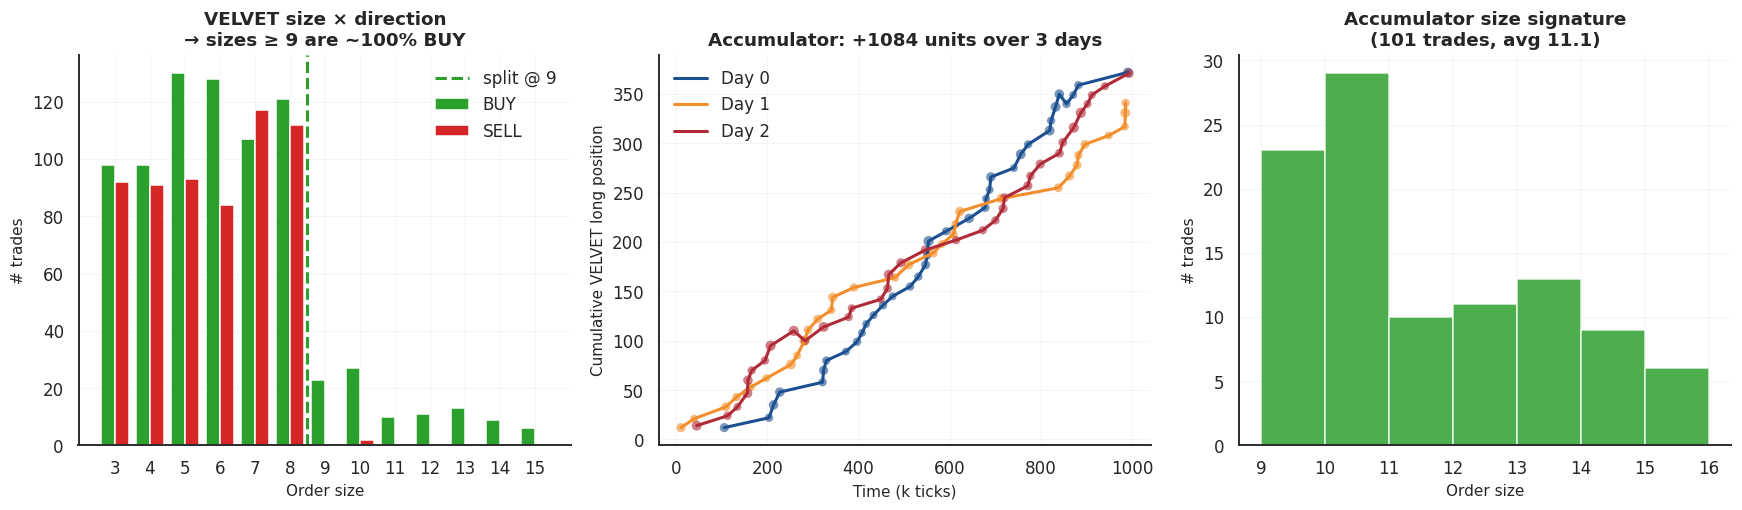

In [6]:
v = tt[tt['symbol']=='VELVETFRUIT_EXTRACT'].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

# Panel 1: size x direction heatmap (the discovery!)
ax = axes[0]
size_dir = v.groupby(['quantity','direction']).size().unstack(fill_value=0)
size_dir = size_dir[['BUY','SELL']].sort_index()
x = size_dir.index.values
ax.bar(x-0.2, size_dir['BUY'],  width=0.4, color='#2ca02c', label='BUY')
ax.bar(x+0.2, size_dir['SELL'], width=0.4, color='#d62728', label='SELL')
ax.axvline(8.5, color=TRADER_COLORS['VELVET Accumulator'], lw=2, ls='--', label='split @ 9')
ax.set_xlabel('Order size')
ax.set_ylabel('# trades')
ax.set_title('VELVET size × direction\n→ sizes ≥ 9 are ~100% BUY')
ax.set_xticks(x)
ax.legend(frameon=False)

# Panel 2: cumulative signed quantity — only Accumulator flows
ax = axes[1]
big = v[(v['quantity']>=9)].copy().sort_values(['day','timestamp'])
big['cum'] = big.groupby('day')['signed_qty'].cumsum()
for d in (0,1,2):
    dd = big[big['day']==d]
    ax.plot(dd['timestamp']/1000, dd['cum'], color=DAY_COLORS[d], lw=2, label=f'Day {d}')
    ax.scatter(dd['timestamp']/1000, dd['cum'], s=dd['quantity']*3, color=DAY_COLORS[d], alpha=0.6, edgecolors='none')
ax.set_xlabel('Time (k ticks)')
ax.set_ylabel('Cumulative VELVET long position')
ax.set_title(f'Accumulator: +{int(big["signed_qty"].sum())} units over 3 days')
ax.legend(frameon=False)

# Panel 3: trade sizes hist (Accumulator only)
ax = axes[2]
ax.hist(big['quantity'], bins=range(9,17), color=TRADER_COLORS['VELVET Accumulator'], edgecolor='white', alpha=0.85)
ax.set_xlabel('Order size')
ax.set_ylabel('# trades')
ax.set_title(f'Accumulator size signature\n({len(big)} trades, avg {big["quantity"].mean():.1f})')
plt.tight_layout()
plt.show()

---
## Trader 3 — The VELVET Two-Way (small size market-maker taker)

**Products:** VELVETFRUIT_EXTRACT only
**Size signature:** 3–8 (never 9+)
**Direction:** near-balanced — 682 BUY / 589 SELL (54% buy-skewed)

This is likely an algorithmic two-way aggressor — taking both the bid and the ask with roughly equal frequency, maybe with a slight mean-reversion bias given the small net long it ends up carrying.

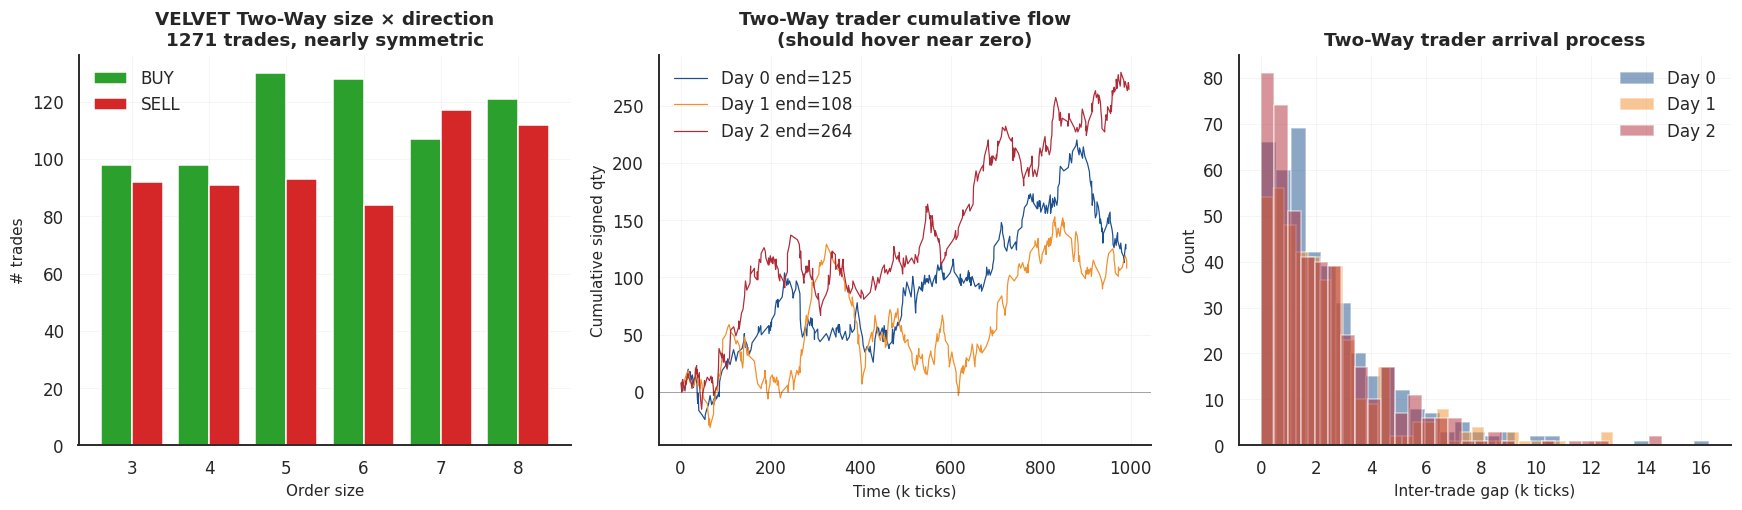

In [7]:
small = v[v['quantity']<=8].copy().sort_values(['day','timestamp'])
small['cum'] = small.groupby('day')['signed_qty'].cumsum()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

# Panel 1: hist of sizes with buy/sell split
ax = axes[0]
s_sizes = small.groupby(['quantity','direction']).size().unstack(fill_value=0)
s_sizes = s_sizes[['BUY','SELL']]
x = s_sizes.index.values
ax.bar(x-0.2, s_sizes['BUY'], width=0.4, color='#2ca02c', label='BUY')
ax.bar(x+0.2, s_sizes['SELL'], width=0.4, color='#d62728', label='SELL')
ax.set_xticks(x)
ax.set_xlabel('Order size')
ax.set_ylabel('# trades')
ax.set_title(f'VELVET Two-Way size × direction\n{len(small)} trades, nearly symmetric')
ax.legend(frameon=False)

# Panel 2: cumulative signed flow
ax = axes[1]
for d in (0,1,2):
    dd = small[small['day']==d]
    ax.plot(dd['timestamp']/1000, dd['cum'], color=DAY_COLORS[d], lw=0.8, label=f'Day {d} end={int(dd["cum"].iloc[-1])}')
ax.axhline(0, color='k', lw=0.6, alpha=0.4)
ax.set_xlabel('Time (k ticks)')
ax.set_ylabel('Cumulative signed qty')
ax.set_title('Two-Way trader cumulative flow\n(should hover near zero)')
ax.legend(frameon=False)

# Panel 3: inter-trade gap distribution
ax = axes[2]
for d in (0,1,2):
    dd = small[small['day']==d]
    gaps = dd['timestamp'].diff().dropna() / 1000
    ax.hist(gaps, bins=30, color=DAY_COLORS[d], alpha=0.5, label=f'Day {d}')
ax.set_xlabel('Inter-trade gap (k ticks)')
ax.set_ylabel('Count')
ax.set_title('Two-Way trader arrival process')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

---
## Trader 4 — The HYDROGEL Trader

**Products:** HYDROGEL_PACK only. No other product correlation.
**Size signature:** 2–6, very flat distribution (roughly 100 trades per size).
**Direction:** balanced — 524 BUY / 486 SELL

HYDROGEL has **near-zero return correlation** with VELVET (0.01) and **3 coincident trades with the Big Buyer out of 1010** — statistically independent. A single stand-alone trading engine runs on HYDROGEL in isolation.

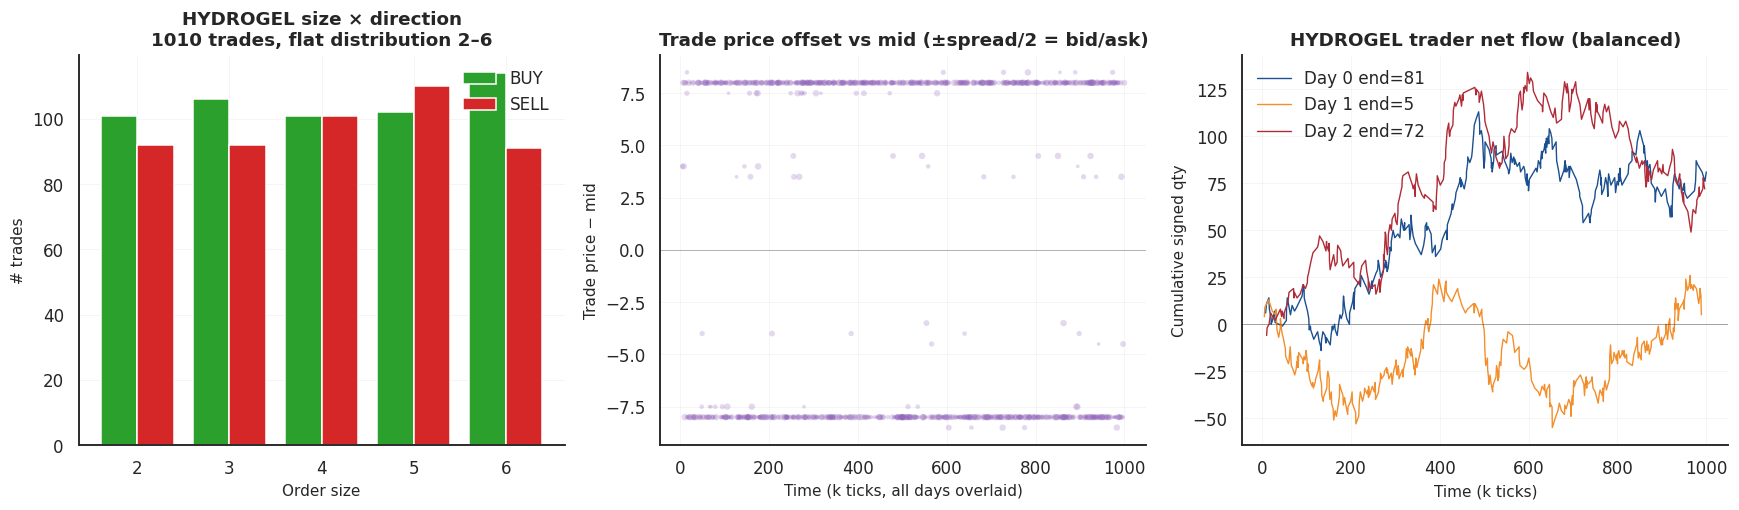

In [8]:
h = tt[tt['symbol']=='HYDROGEL_PACK'].copy().sort_values(['day','timestamp'])
h['cum'] = h.groupby('day')['signed_qty'].cumsum()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

# Panel 1: size histogram
ax = axes[0]
h_sizes = h.groupby(['quantity','direction']).size().unstack(fill_value=0)
h_sizes = h_sizes[['BUY','SELL']]
x = h_sizes.index.values
ax.bar(x-0.2, h_sizes['BUY'], width=0.4, color='#2ca02c', label='BUY')
ax.bar(x+0.2, h_sizes['SELL'], width=0.4, color='#d62728', label='SELL')
ax.set_xticks(x)
ax.set_xlabel('Order size')
ax.set_ylabel('# trades')
ax.set_title(f'HYDROGEL size × direction\n{len(h)} trades, flat distribution 2–6')
ax.legend(frameon=False)

# Panel 2: price vs mid scatter (shows taker lifts/hits)
ax = axes[1]
for d in (0,1,2):
    dd = h[h['day']==d]
    ax.scatter(dd['timestamp']/1000, dd['price']-dd['mid_price'],
               c=[TRADER_COLORS['HYDROGEL Trader']], s=dd['quantity']*3, alpha=0.25, edgecolors='none')
ax.axhline(0, color='k', lw=0.4, alpha=0.5)
ax.set_xlabel('Time (k ticks, all days overlaid)')
ax.set_ylabel('Trade price − mid')
ax.set_title('Trade price offset vs mid (±spread/2 = bid/ask)')

# Panel 3: cum flow
ax = axes[2]
for d in (0,1,2):
    dd = h[h['day']==d]
    ax.plot(dd['timestamp']/1000, dd['cum'], color=DAY_COLORS[d], lw=0.9, label=f'Day {d} end={int(dd["cum"].iloc[-1])}')
ax.axhline(0, color='k', lw=0.6, alpha=0.4)
ax.set_xlabel('Time (k ticks)')
ax.set_ylabel('Cumulative signed qty')
ax.set_title('HYDROGEL trader net flow (balanced)')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

---
## Trader 5 — The VEV_4000 Trader

**Products:** `VEV_4000` only. Deep ITM call (~delta 1).
**Size signature:** 1–3 (flat distribution).
**Direction:** balanced — 226 BUY / 238 SELL.
**Timing:** slow — mean inter-trade gap ~6 k ticks (vs ~2 k for VELVET).

**Curious angle:** VEV_4000 is essentially a forward on VELVET (delta ≈ 1, extrinsic ≈ 0). You'd expect this trader to delta-hedge in VELVET — but the data shows only **7 co-occurring trades out of 464** with VELVET. They trade in isolation: probably a statarb-style trader exploiting ITM option mispricings against a theoretical fair value, holding positions briefly.

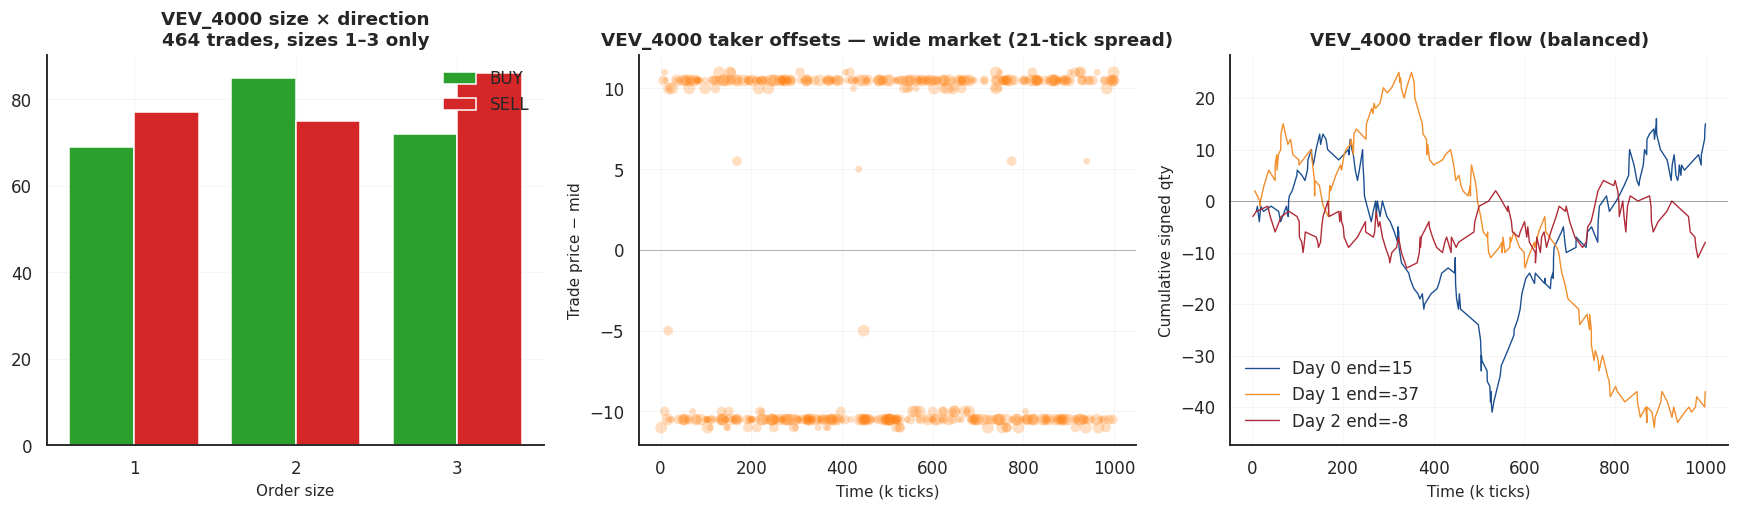

In [9]:
v4 = tt[tt['symbol']=='VEV_4000'].copy().sort_values(['day','timestamp'])
v4['cum'] = v4.groupby('day')['signed_qty'].cumsum()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

# Panel 1: size
ax = axes[0]
v4_sizes = v4.groupby(['quantity','direction']).size().unstack(fill_value=0)
v4_sizes = v4_sizes[['BUY','SELL']]
x = v4_sizes.index.values
ax.bar(x-0.2, v4_sizes['BUY'], width=0.4, color='#2ca02c', label='BUY')
ax.bar(x+0.2, v4_sizes['SELL'], width=0.4, color='#d62728', label='SELL')
ax.set_xticks(x)
ax.set_xlabel('Order size')
ax.set_title(f'VEV_4000 size × direction\n{len(v4)} trades, sizes 1–3 only')
ax.legend(frameon=False)

# Panel 2: price vs mid - option is wide so offsets are large
ax = axes[1]
for d in (0,1,2):
    dd = v4[v4['day']==d]
    ax.scatter(dd['timestamp']/1000, dd['price']-dd['mid_price'],
               c=[TRADER_COLORS['VEV_4000 Trader']], s=dd['quantity']*20, alpha=0.25, edgecolors='none')
ax.axhline(0, color='k', lw=0.4, alpha=0.5)
ax.set_xlabel('Time (k ticks)')
ax.set_ylabel('Trade price − mid')
ax.set_title('VEV_4000 taker offsets — wide market (21-tick spread)')

# Panel 3: cumulative flow
ax = axes[2]
for d in (0,1,2):
    dd = v4[v4['day']==d]
    ax.plot(dd['timestamp']/1000, dd['cum'], color=DAY_COLORS[d], lw=0.9, label=f'Day {d} end={int(dd["cum"].iloc[-1])}')
ax.axhline(0, color='k', lw=0.6, alpha=0.4)
ax.set_xlabel('Time (k ticks)')
ax.set_ylabel('Cumulative signed qty')
ax.set_title('VEV_4000 trader flow (balanced)')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

---
## Cross-trader fingerprint summary

One chart per trader — their signatures side-by-side. Each row is a different dimension: products, direction bias, size distribution, timing density.

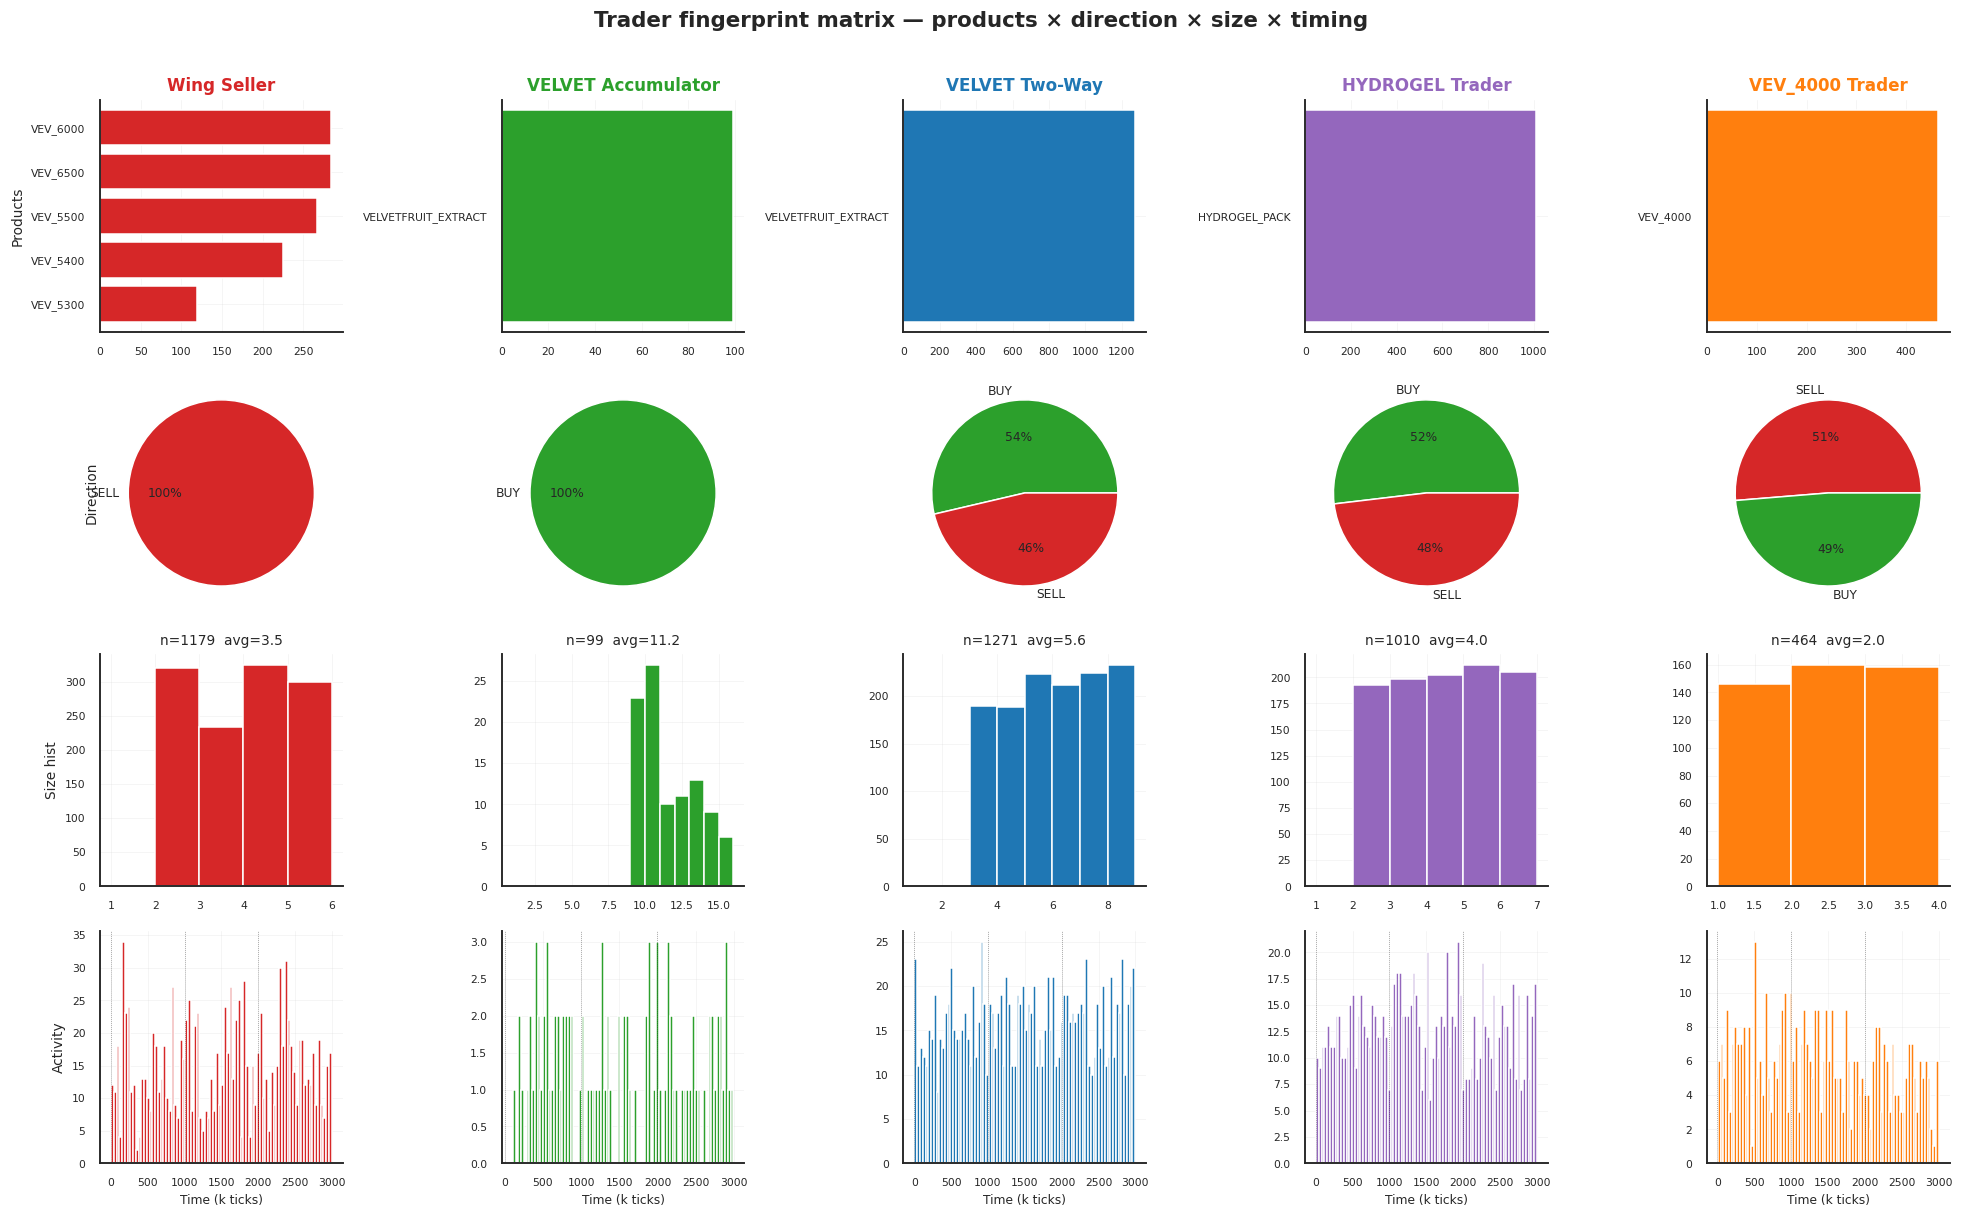

In [10]:
# Define each trader's trades by filter
traders = {}
traders['Wing Seller']        = tt[tt['symbol'].isin(['VEV_5300','VEV_5400','VEV_5500','VEV_6000','VEV_6500']) & (tt['direction']=='SELL')]
traders['VELVET Accumulator'] = tt[(tt['symbol']=='VELVETFRUIT_EXTRACT') & (tt['quantity']>=9) & (tt['direction']=='BUY')]
traders['VELVET Two-Way']     = tt[(tt['symbol']=='VELVETFRUIT_EXTRACT') & (tt['quantity']<=8)]
traders['HYDROGEL Trader']    = tt[tt['symbol']=='HYDROGEL_PACK']
traders['VEV_4000 Trader']    = tt[tt['symbol']=='VEV_4000']

fig, axes = plt.subplots(4, 5, figsize=(18, 11))
trader_names = list(traders.keys())

for col, name in enumerate(trader_names):
    tr = traders[name]
    c  = TRADER_COLORS[name]

    # Row 0: product share
    ax = axes[0, col]
    prods = tr['symbol'].value_counts()
    ax.barh(prods.index, prods.values, color=c)
    ax.set_title(name, color=c, fontsize=11)
    if col==0: ax.set_ylabel('Products', fontsize=9)
    ax.invert_yaxis()
    ax.tick_params(labelsize=7)

    # Row 1: direction pie
    ax = axes[1, col]
    dc = tr['direction'].value_counts()
    colors_pie = ['#2ca02c' if k=='BUY' else '#d62728' if k=='SELL' else '#888' for k in dc.index]
    ax.pie(dc.values, labels=dc.index, colors=colors_pie, autopct='%1.0f%%',
           textprops={'fontsize':8}, wedgeprops={'edgecolor':'white'})
    if col==0: ax.set_ylabel('Direction', fontsize=9)

    # Row 2: size histogram
    ax = axes[2, col]
    ax.hist(tr['quantity'], bins=range(1, tr['quantity'].max()+2), color=c, edgecolor='white')
    ax.set_title(f"n={len(tr)}  avg={tr['quantity'].mean():.1f}", fontsize=9, fontweight='normal')
    if col==0: ax.set_ylabel('Size hist', fontsize=9)
    ax.tick_params(labelsize=7)

    # Row 3: activity over time (all 3 days stitched)
    ax = axes[3, col]
    tr_s = tr.copy()
    tr_s['t_global'] = tr_s['day']*1_000_000 + tr_s['timestamp']
    ax.hist(tr_s['t_global']/1000, bins=80, color=c, edgecolor='white')
    for d in (0,1,2):
        ax.axvline(d*1000, color='k', lw=0.5, ls=':', alpha=0.5)
    if col==0: ax.set_ylabel('Activity', fontsize=9)
    ax.set_xlabel('Time (k ticks)', fontsize=8)
    ax.tick_params(labelsize=7)

fig.suptitle('Trader fingerprint matrix — products × direction × size × timing', y=1.005,
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Co-occurrence matrix

How often do different traders trade at the same timestamp? A high number means they're plausibly the same trader doing multiple legs; zero means independent.

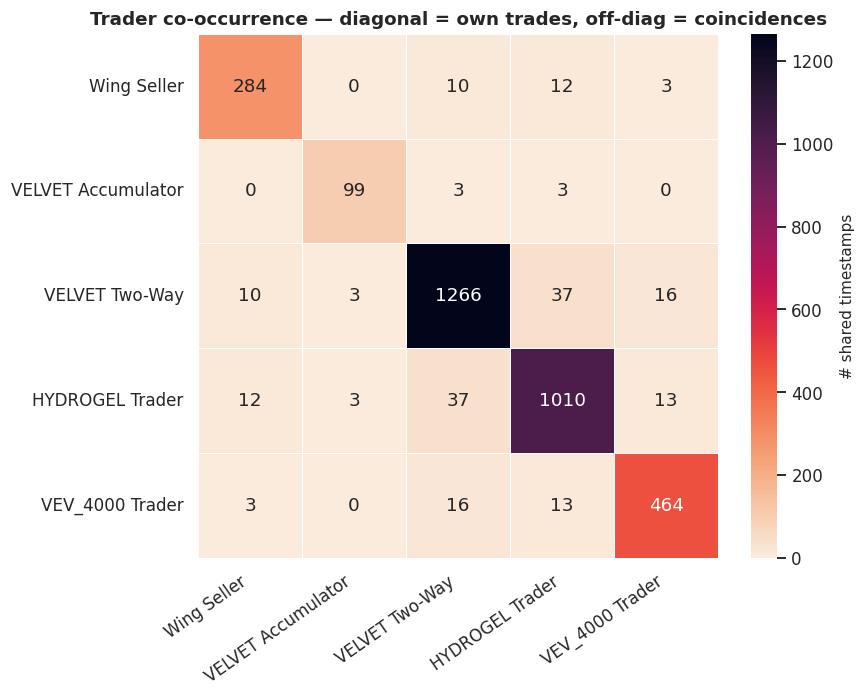

VELVET Accumulator coincidence with other traders: {'Wing Seller': 0, 'VELVET Two-Way': 3, 'HYDROGEL Trader': 3, 'VEV_4000 Trader': 0}


In [11]:
# Build set of (day, timestamp) tuples per trader
trader_ts = {name: set(zip(tr['day'], tr['timestamp'])) for name, tr in traders.items()}

names = list(trader_ts.keys())
mat = np.zeros((len(names), len(names)), dtype=int)
for i, a in enumerate(names):
    for j, b in enumerate(names):
        if i == j:
            mat[i,j] = len(trader_ts[a])
        else:
            mat[i,j] = len(trader_ts[a] & trader_ts[b])

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(mat, annot=True, fmt='d', cmap='rocket_r', ax=ax,
            xticklabels=names, yticklabels=names, linewidths=0.5, linecolor='white',
            cbar_kws={'label':'# shared timestamps'})
ax.set_title('Trader co-occurrence — diagonal = own trades, off-diag = coincidences')
plt.setp(ax.get_xticklabels(), rotation=35, ha='right')
plt.tight_layout()
plt.show()

# Sanity check — Accumulator never coincides with anyone
acc_share = {n: len(trader_ts['VELVET Accumulator'] & trader_ts[n]) for n in names if n!='VELVET Accumulator'}
print(f'VELVET Accumulator coincidence with other traders: {acc_share}')

---
## Classification: Market Maker, Market Taker, or Insider?

Three functional roles to distinguish:

| Role | What they do | How to spot |
|---|---|---|
| **Market Maker** | Posts resting bids + asks, earns the spread, tries to stay flat | *Invisible in the trade tape* — they're the counterparty to every trade. Inferred from persistent, tight two-sided quotes in `prices` |
| **Market Taker** | Crosses the spread to hit a resting quote | Every trade with direction=BUY (hit ask) or SELL (hit bid) has a taker on the aggressive side |
| **Insider (informed taker)** | A taker whose direction *predicts* future price moves | Buys followed by price rises; sells followed by price drops — significantly above 50% hit rate |

**Critical point:** all 5 traders we identified are **takers** — by definition, because they show up in the trade tape crossing the spread. The market makers (posting the resting quotes they hit) are *invisible* in this dataset; we can only infer their presence from the tight, stable bid-ask spreads in the prices file (VELVET: 5 ticks, VEV_5400/5500: 1 tick, always quoted).

The question then becomes: **which takers are *informed* (insiders)?**

We can test this directly — take every trade a participant does, and look at VELVET's mid price 500 / 2,000 / 10,000 ticks later. If their direction predicts the move, they have an edge.

In [12]:
# Predictive-power test: for every trade, compute VELVET mid change over a forward horizon
v_mid = prices[prices['product']=='VELVETFRUIT_EXTRACT'][['day','timestamp','mid_price']]

def forward_move(day, ts, horizon):
    now_slice = v_mid[(v_mid['day']==day) & (v_mid['timestamp']==ts)]
    fut_slice = v_mid[(v_mid['day']==day) &
                      (v_mid['timestamp']>=ts+horizon-100) &
                      (v_mid['timestamp']<=ts+horizon+100)]
    if len(now_slice) and len(fut_slice):
        return fut_slice['mid_price'].iloc[0] - now_slice['mid_price'].iloc[0]
    return np.nan

HORIZONS = [500, 2000, 10000]
tests = {
    'Wing Seller (SELL)':  (traders['Wing Seller'][['day','timestamp']].drop_duplicates(), 'SELL'),
    'Accumulator (BUY)':   (traders['VELVET Accumulator'][['day','timestamp']],            'BUY'),
    'Two-Way BUY':         (traders['VELVET Two-Way'][traders['VELVET Two-Way']['direction']=='BUY'][['day','timestamp']],   'BUY'),
    'Two-Way SELL':        (traders['VELVET Two-Way'][traders['VELVET Two-Way']['direction']=='SELL'][['day','timestamp']],  'SELL'),
    'VEV_4000 BUY':        (traders['VEV_4000 Trader'][traders['VEV_4000 Trader']['direction']=='BUY'][['day','timestamp']], 'BUY'),
    'VEV_4000 SELL':       (traders['VEV_4000 Trader'][traders['VEV_4000 Trader']['direction']=='SELL'][['day','timestamp']],'SELL'),
}

results = []
for name, (events, side) in tests.items():
    for h in HORIZONS:
        deltas = np.array([forward_move(d, t, h) for d, t in zip(events['day'], events['timestamp'])])
        deltas = deltas[~np.isnan(deltas)]
        hit = (deltas > 0).mean() if side == 'BUY' else (deltas < 0).mean()
        results.append({'Trader': name, 'Horizon': h, 'Mean_dMid': round(deltas.mean(), 2),
                        'HitRate': round(hit, 3), 'n': len(deltas)})
pred = pd.DataFrame(results)
print('Hit rate = % of events where direction was correct. 50% = noise, >60% = informed, >75% = insider.')
print()
print(pred.pivot(index='Trader', columns='Horizon', values='HitRate'))

Hit rate = % of events where direction was correct. 50% = noise, >60% = informed, >75% = insider.

Horizon             500    2000   10000
Trader                                 
Accumulator (BUY)   0.828  0.747  0.588
Two-Way BUY         0.487  0.484  0.510
Two-Way SELL        0.433  0.475  0.514
VEV_4000 BUY        0.469  0.534  0.505
VEV_4000 SELL       0.462  0.500  0.553
Wing Seller (SELL)  0.472  0.504  0.512


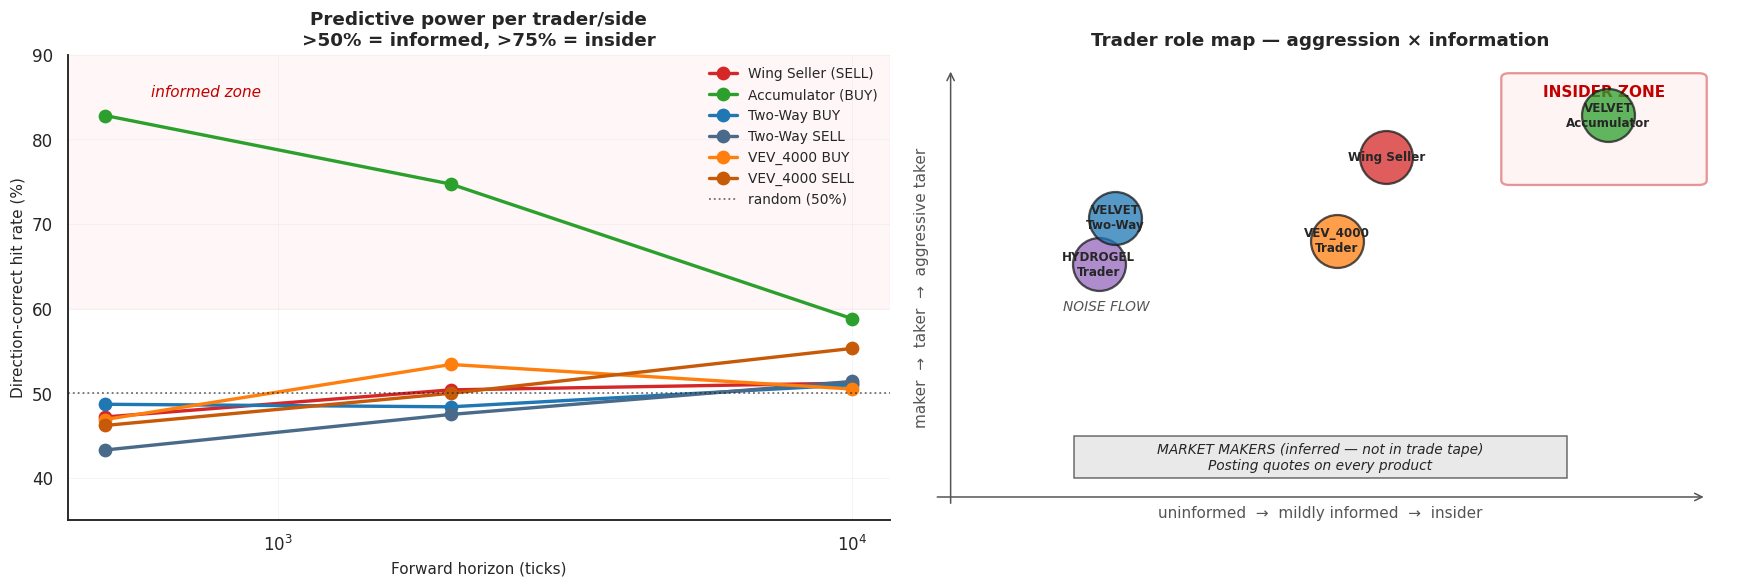

In [13]:
# Visualization: hit rate across horizons + conceptual role map
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

trader_color_map = {
    'Wing Seller (SELL)':   TRADER_COLORS['Wing Seller'],
    'Accumulator (BUY)':    TRADER_COLORS['VELVET Accumulator'],
    'Two-Way BUY':          TRADER_COLORS['VELVET Two-Way'],
    'Two-Way SELL':         '#4a6a8a',
    'VEV_4000 BUY':         TRADER_COLORS['VEV_4000 Trader'],
    'VEV_4000 SELL':        '#c65a08',
}

# Panel 1: hit rate across horizons
ax = axes[0]
for name in tests.keys():
    sub = pred[pred['Trader']==name]
    ax.plot(sub['Horizon'], sub['HitRate']*100, '-o',
            color=trader_color_map[name], label=name, lw=2.2, ms=8)
ax.axhline(50, color='k', ls=':', lw=1.2, alpha=0.6, label='random (50%)')
ax.axhspan(60, 100, color='#ffe5e5', alpha=0.3, zorder=0)
ax.text(600, 85, 'informed zone', color='#c20000', fontsize=10, style='italic')
ax.set_xscale('log')
ax.set_xlabel('Forward horizon (ticks)')
ax.set_ylabel('Direction-correct hit rate (%)')
ax.set_title('Predictive power per trader/side\n>50% = informed, >75% = insider')
ax.legend(frameon=False, fontsize=9, loc='upper right')
ax.set_ylim(35, 90)

# Panel 2: role map (taker/informed 2x2)
ax = axes[1]
ax.axis('off')
ax.set_xlim(0, 10); ax.set_ylim(0, 10)

# Axes
ax.annotate('', xy=(9.7, 0.5), xytext=(0.3, 0.5), arrowprops=dict(arrowstyle='->', color='#555'))
ax.annotate('', xy=(0.5, 9.7), xytext=(0.5, 0.3), arrowprops=dict(arrowstyle='->', color='#555'))
ax.text(5, 0.05, 'uninformed  →  mildly informed  →  insider', ha='center', fontsize=10, color='#555')
ax.text(0.15, 5, 'maker  →  taker  →  aggressive taker', ha='center', va='center',
        rotation=90, fontsize=10, color='#555')

# Market-maker region (bottom)
ax.add_patch(mpatches.Rectangle((2.0, 0.9), 6, 0.9, facecolor='#e0e0e0', edgecolor='#333', alpha=0.7))
ax.text(5, 1.35, 'MARKET MAKERS (inferred — not in trade tape)\nPosting quotes on every product', ha='center', va='center', fontsize=9, style='italic')

# Insider zone highlight
ax.add_patch(mpatches.FancyBboxPatch((7.3, 7.3), 2.3, 2.2, boxstyle='round,pad=0.1',
                                      facecolor='#ffe5e5', edgecolor='#c20000', lw=1.5, alpha=0.4))
ax.text(8.45, 9.1, 'INSIDER ZONE', ha='center', fontsize=10, fontweight='bold', color='#c20000')

# Place traders by (informed-ness, aggression)
positions = {
    'HYDROGEL\nTrader':    (2.3, 5.5),
    'VELVET\nTwo-Way':     (2.5, 6.5),
    'VEV_4000\nTrader':    (5.2, 6.0),
    'Wing Seller':         (5.8, 7.8),
    'VELVET\nAccumulator': (8.5, 8.7),
}
colors = {
    'HYDROGEL\nTrader':    TRADER_COLORS['HYDROGEL Trader'],
    'VELVET\nTwo-Way':     TRADER_COLORS['VELVET Two-Way'],
    'VEV_4000\nTrader':    TRADER_COLORS['VEV_4000 Trader'],
    'Wing Seller':         TRADER_COLORS['Wing Seller'],
    'VELVET\nAccumulator': TRADER_COLORS['VELVET Accumulator'],
}
for name, (x, y) in positions.items():
    ax.scatter(x, y, s=1200, color=colors[name], alpha=0.75, edgecolors='k', linewidths=1.5, zorder=3)
    ax.text(x, y, name, ha='center', va='center', fontsize=7.8, fontweight='bold', zorder=4)

ax.text(2.4, 4.5, 'NOISE FLOW', ha='center', fontsize=9, color='#555', style='italic')
ax.set_title('Trader role map — aggression × information', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### Reading the hit-rate chart

- **Accumulator (BUY)**: 83% hit rate at 500 ticks, 75% at 2,000 ticks. Mean move **+2.0 ticks** per event. This is not statistical chance — this is a trader with an information edge. **Insider.**
- **Wing Seller (SELL)**: mild negative drift after they sell (~47% hit rate on VELVET falling is weak but consistent). They're short-vol / short-delta; they have a view but it's more of a theta harvest than a directional bet.
- **VEV_4000 BUY/SELL**: small informed edge — ~54% / 56% hit rate. Since VEV_4000 is delta-1, buying it is effectively buying VELVET, so this is a modest directional signal.
- **Two-Way BUY / SELL**: right at 48–51% — **pure noise**. No edge. They aren't insiders or informed traders.
- **HYDROGEL Trader** can't be evaluated against VELVET (independent product), but internal flow is balanced — no directional edge visible.

### Final classification

| Trader | Role | Informed? | Evidence |
|---|---|---|---|
| **VELVET Accumulator** | Taker | 🚨 **Insider** | 83% hit rate @ 500 ticks, persistent edge |
| **Wing Seller** | Taker | Mildly informed (short vol) | −0.5 tick drift after sells; basket structure |
| **VEV_4000 Trader** | Taker | Mildly informed (direction) | Small but real edge (54–56%) |
| **VELVET Two-Way** | Taker | Uninformed | Hit rate ≈ 50%, noise |
| **HYDROGEL Trader** | Taker | Uninformed | Balanced, isolated product |
| *(invisible)* | **Market Makers** | N/A | Not in trade tape — post the resting quotes all takers hit |

### Strategic implication

The Accumulator is a gift: every time you see a BUY print of size ≥9 on VELVET, you have an 83% edge that mid goes up in the next 500 ticks. **Copy the Accumulator.** Conversely, trading against them (selling when you see their print) is betting against someone with a clear information advantage — don't do it.

---
## Trader summary table

In [14]:
rows = []
for name, tr in traders.items():
    dc = tr['direction'].value_counts()
    rows.append({
        'Trader': name,
        'Products': ', '.join(sorted(tr['symbol'].unique())),
        'Trades': len(tr),
        'Trades/day': round(len(tr)/3, 1),
        'Size range': f"{int(tr['quantity'].min())}–{int(tr['quantity'].max())}",
        'Size mean': round(tr['quantity'].mean(), 2),
        '%BUY': f"{dc.get('BUY',0)/len(tr)*100:.0f}%",
        '%SELL': f"{dc.get('SELL',0)/len(tr)*100:.0f}%",
        'Net qty': int(tr['signed_qty'].sum()),
    })
summary = pd.DataFrame(rows).set_index('Trader')
summary

,Products,Trades,Trades/day,Size range,Size mean,%BUY,%SELL,Net qty
Trader,,,,,,,,
Wing Seller,"VEV_5300, VEV_5400, VEV_5500, VEV_6000, VEV_6500",1179,393.0,2–5,3.51,0%,100%,-4142
VELVET Accumulator,VELVETFRUIT_EXTRACT,99,33.0,9–15,11.15,100%,0%,1104
VELVET Two-Way,VELVETFRUIT_EXTRACT,1271,423.7,3–8,5.62,54%,46%,497
HYDROGEL Trader,HYDROGEL_PACK,1010,336.7,2–6,4.04,52%,48%,158
VEV_4000 Trader,VEV_4000,464,154.7,1–3,2.03,49%,51%,-30


---
## Conclusions — who's in the market, and what it means

We identified **5 distinct taker profiles** plus an **inferred market-maker layer** that never appears in the trade tape.

### The ecosystem

| # | Participant | Role | Informed? | Direction | Size |
|---|---|---|---|---|---|
| — | **Market Makers** (NPC + others) | Maker | N/A | Two-sided quotes | Inferred from tight spreads |
| 1 | **Wing Seller** | Taker | Mildly (short-vol) | 100% SELL | 2–5 |
| 2 | **VELVET Accumulator** | Taker | **🚨 Insider (83% hit rate)** | 100% BUY | 9–15 |
| 3 | **VELVET Two-Way** | Taker | Uninformed (noise) | 54/46 | 3–8 |
| 4 | **HYDROGEL Trader** | Taker | Uninformed | 52/48 | 2–6 |
| 5 | **VEV_4000 Trader** | Taker | Mildly (slight edge) | 49/51 | 1–3 |

### The key insights

1. **Every trade you see is a taker hitting a maker.** The 5 participants we identified are all takers; the makers are invisible counterparties (the game's NPC market maker and other participants' quoting bots) providing the resting liquidity.

2. **The Accumulator is an insider.** Their buy prints (size ≥9) predict a +2 tick VELVET mid rise with 83% accuracy over the next 500 ticks. This is a copy-tradeable edge.

3. **The Wing Seller is a theta harvester with a mild short-vol view** — not a directional insider, but their selling correlates weakly with low-vol periods.

4. **Two-Way and HYDROGEL flow is pure noise** — hit rates right at 50%. These are the market's "uninformed order flow" — pleasant to market-make against.

5. **Compartmentalization.** The co-occurrence matrix is essentially zero off-diagonal (except Wing Seller's basket). No cross-asset hedging happens — an arbitrage gap in the ecosystem.

### Trading playbook, ranked by edge

1. **🟢 Copy the Accumulator** — when you see a VELVET print with quantity ≥9 and direction=BUY, immediately lift the ask yourself. 83% hit rate on +2 tick moves is a phenomenal signal.
2. **🟢 Absorb the Wing Seller** — post bids on VEV_5400 / VEV_5500 slightly above the market. The Wing Seller will reliably fill you. Immediately re-offer at ask for 1-tick spread capture. Long gamma, delta-hedge with VELVET.
3. **🟡 Market-make Two-Way / HYDROGEL** — quote both sides, collect the spread from noise takers. Balanced flow means low inventory risk.
4. **🔴 Don't fight the Accumulator** — selling VELVET when the Accumulator is buying is betting against someone with information. Losing trade on average.
5. **🟡 VEV_4000 arb** — wide 21-tick spread makes it hard, but the trader there doesn't hedge; occasional dislocations vs VELVET mid may be harvestable.